<a href="https://www.kaggle.com/code/samratrm/gemstone-linear-regression?scriptVersionId=325222547" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Gemstone Price Prediction using Linear Regression

This notebook is designed for learning and hands-on practice with a complete machine learning workflow. It is beginner-friendly and explains each concept step by step.

In this project, we work with a gemstone dataset and go through the entire data science process, including:

* Data Understanding – Exploring the dataset, understanding features, and identifying the target variable.
* Data Cleaning – Handling missing values, duplicates, incorrect data types, and other data quality issues.
* Exploratory Data Analysis (EDA) – Visualizing data distributions, discovering patterns, relationships, and insights using charts and statistical summaries.
* Feature Engineering – Creating, transforming, and selecting features to improve model performance.
* Data Preprocessing – Encoding categorical variables, scaling numerical features, and preparing data for machine learning algorithms.
* Model Building – Training a Linear Regression model to predict gemstone prices.
* Model Evaluation – Measuring performance using appropriate evaluation metrics and interpreting the results.
* Key Learnings and Insights – Understanding how each step contributes to building an effective machine learning model.

Every stage is explained in simple language with detailed comments and examples, making this notebook suitable for beginners who want to understand not only how to build a machine learning model, but also why each step is important.

### Initial Setup 

In [567]:
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt 
import seaborn as sns 
import os

import sklearn

In [568]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s3e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s3e8/train.csv
/kaggle/input/competitions/playground-series-s3e8/test.csv


In [569]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s3e8/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s3e8/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/playground-series-s3e8/sample_submission.csv")

In [570]:
train.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


## Data Understanding

### Data Description 

`id` — your uniqur row ID

`carat` — the diamond's weight. Carat refers to the unit of weight measurement used exclusively to weigh gemstones and diamonds. This is usually the single strongest predictor of price.

`cut` — quality of the cut (how well-proportioned it is). An ordered quality grade, typically Fair < Good < Very Good < Premium < Ideal.

`color` — diamond color grade, lettered D (best, colorless) through J (more tinted). Counterintuitively, *earlier* letters are better.

`clarity` — how free of internal flaws it is. Clarity is a measure of the purity and rarity of the stone, graded by the visibility of characteristics under 10-power magnification. Ordered worst-to-best roughly: I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF.

`depth` — the diamond's height as a percentage. It's the height in millimeters measured from the culet (bottom tip) to the table (flat top surface), expressed relative to width.

`table` — the facet you see when the stone is viewed face-up, as a percentage of the diamond's width.

`x`, `y`, `z` — the physical dimensions in millimeters (length, width, depth). These are where you'll spot the `0` values that are physically impossible — the data-cleaning catch I mentioned.

`price` — your target, in US dollars.

In [571]:
test.head()

,id,carat,cut,color,clarity,depth,table,x,y,z
0,193573,0.35,Ideal,D,VS2,62.3,56.0,4.51,4.54,2.82
1,193574,0.77,Very Good,F,SI2,62.8,56.0,5.83,5.87,3.68
2,193575,0.71,Ideal,I,VS2,61.9,53.0,5.77,5.74,3.55
3,193576,0.33,Ideal,G,VVS2,61.6,55.0,4.44,4.42,2.73
4,193577,1.20,Very Good,I,VS2,62.7,56.0,6.75,6.79,4.24


The target variable is the `price` column. 


#### Initial Intuition 

- The price of a gemstone depends on the carat, size and scarcity.
    - Large gemstones are rare and are more expensive. So, higher the carat the price increases non linearly.
    - And the size of the stone matters as much as carat. 
    - The scarcity is not a factor in our dataset. But its hidden in other features.
        -  Big, flawless, colorless stones are exactly what's rare. 
- The cut, colour and clarity is also a factor.
    - Cut refers to how well the gemstone is shaped and polished. Better cuts are sparkels more.
    - Colour is also a importnat factor (D-J grade). (image attached for reference)
    - Clarity refers to imperfections on the surface of the gemstone. Fewer imperfections means more value.

-> We can see after the regression what and how much importance our model gives to each features.

In [572]:
train['color'].value_counts()

color
G    44391
E    35869
F    34258
H    30799
D    24286
I    17514
J     6456
Name: count, dtype: int64

In [573]:
sample.head()

,id,price
0,193573,3969.155
1,193574,3969.155
2,193575,3969.155
3,193576,3969.155
4,193577,3969.155


In [574]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


We might have to convert `cut` , `color` and `clarity` into categorical data. Since, we can't input string data in the ML model. 

In [575]:
train.describe()

,id,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,96786.000000,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,55879.856166,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.000000,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,48393.000000,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,96786.000000,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,145179.000000,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,193572.000000,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


There is no `nan` data which we can see in the count. But there might be some outliars and bad data which we will remove in data cleaning. Like the `x`,`y`,`z` being 0 which is bad because height, width and depth can't be 0. 

## Data Cleaning 

Delete the `id` column. Since it can't use as a input to train the model. Its not a feature.

In [576]:
train = train.drop("id",axis=1)
test = test.drop("id",axis=1)

train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


Now, Lets delete all the impossible rows (bad data)

Like the rows that are 0 for measurements like length, width and depth

In [577]:
train.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

There is no rows with `nan` values.

In [578]:
(train[['x','y','z']] == 0).any(axis=1).sum()

np.int64(10)

There are 10 rows that have atleast one data point or row (x,y,z) as 0

In [579]:
index = (train[['x','y','z']] != 0).all(axis=1)
train = train[index]
train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [580]:
(train[['x','y','z']] == 0).any(axis=1).sum()

np.int64(0)

All the x,y,z data points that had atleast one value as 0 are deleted.

In [581]:
train.duplicated().sum()

np.int64(0)

There is no duplicate row.

In [582]:
train.describe()

,carat,depth,table,x,y,z,price
count,193563.000000,193563.000000,193563.000000,193563.000000,193563.000000,193563.000000,193563.000000
mean,0.790645,61.820608,57.227547,5.715312,5.720061,3.534429,3968.858687
std,0.462634,1.081658,1.918787,1.109117,1.102104,0.688471,4034.020215
min,0.200000,52.100000,49.000000,3.750000,3.710000,1.050000,326.000000
25%,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,950.000000
50%,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5407.500000
max,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


We have removed all the nan and impossible data from the x,y,z rows. Now lets work on the outliars. 

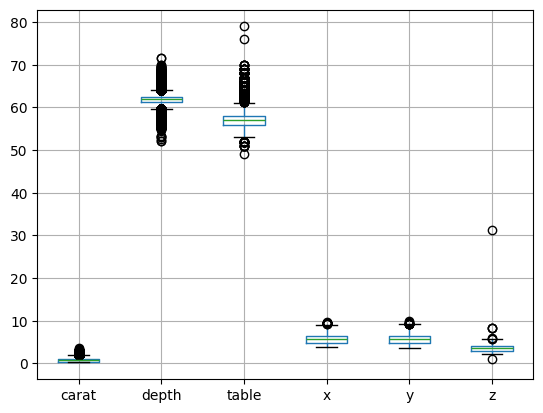

In [583]:
train[['carat','depth','table','x','y','z']].boxplot()
plt.show()

In [584]:
train[train['z']>train['x']].shape

(3, 10)

So, there are 3 stones that have depth higher than the length. 

Higher depth means bigger size means higher cost. So, Lets skip removing the max side outliars for now. We can focus on this after out firt model evaluation. 

In [585]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193563 entries, 0 to 193572
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   carat    193563 non-null  float64
 1   cut      193563 non-null  object 
 2   color    193563 non-null  object 
 3   clarity  193563 non-null  object 
 4   depth    193563 non-null  float64
 5   table    193563 non-null  float64
 6   x        193563 non-null  float64
 7   y        193563 non-null  float64
 8   z        193563 non-null  float64
 9   price    193563 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 16.2+ MB


Columns `clarity` , `cut` , `colour` are all categorical data. So, lets change the datatypes. 

In [586]:
cat_cols = train.select_dtypes(include='object').columns
train[cat_cols] = train[cat_cols].astype('category')
test[cat_cols] = test[cat_cols].astype('category')
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193563 entries, 0 to 193572
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   carat    193563 non-null  float64 
 1   cut      193563 non-null  category
 2   color    193563 non-null  category
 3   clarity  193563 non-null  category
 4   depth    193563 non-null  float64 
 5   table    193563 non-null  float64 
 6   x        193563 non-null  float64 
 7   y        193563 non-null  float64 
 8   z        193563 non-null  float64 
 9   price    193563 non-null  int64   
dtypes: category(3), float64(6), int64(1)
memory usage: 12.4 MB


In [587]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129050 entries, 0 to 129049
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   carat    129050 non-null  float64 
 1   cut      129050 non-null  category
 2   color    129050 non-null  category
 3   clarity  129050 non-null  category
 4   depth    129050 non-null  float64 
 5   table    129050 non-null  float64 
 6   x        129050 non-null  float64 
 7   y        129050 non-null  float64 
 8   z        129050 non-null  float64 
dtypes: category(3), float64(6)
memory usage: 6.3 MB


### Data Cleaning Summary:

- Removed the `id` column.
- Checked for `nan` and duplicate rows. No data found
- Removed the (min side outliars) impossible values for x,y,z columns which was removing all the rows which had 0.
- The max side outliars are not removed. It will be worked on after the initial model evaluation.
- Changed dtype for categorical data.

## EDA 

<Axes: >

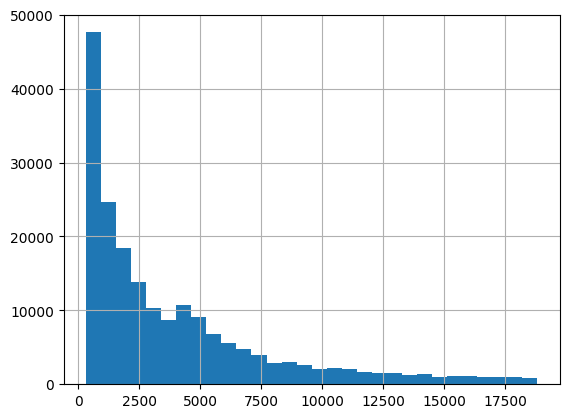

In [588]:
train['price'].hist(bins=30)

In [589]:
train['price'].skew()

np.float64(1.6056983504430278)

The data is heavily right skewed. Linear regression assumes that errors are roughly normally distributed and have constant variance. With a heavily skewed target, large values dominate the loss function because squared errors explode.

We should do `np.log1p()` to make it more normally distributed. So, the model learns relative differences rather than absolute differences. 

We do this in the Feature engineering section to avoid disturbing the other price related EDA. 

In [590]:
train.corr(numeric_only=True)['price'].sort_values(ascending=False)

price    1.000000
carat    0.943388
x        0.901132
y        0.901117
z        0.894124
table    0.174868
depth    0.002005
Name: price, dtype: float64

Note: Remember the depth is a percent realtive to width. And Z is the measurement of depth. 

- Size dominates. x,y,z are very strongly related to price.
- Weight also matters as much as size. Its also very strongly related.
- Table and depth are weak but we will keep them and let the model regularization decide the importance. 

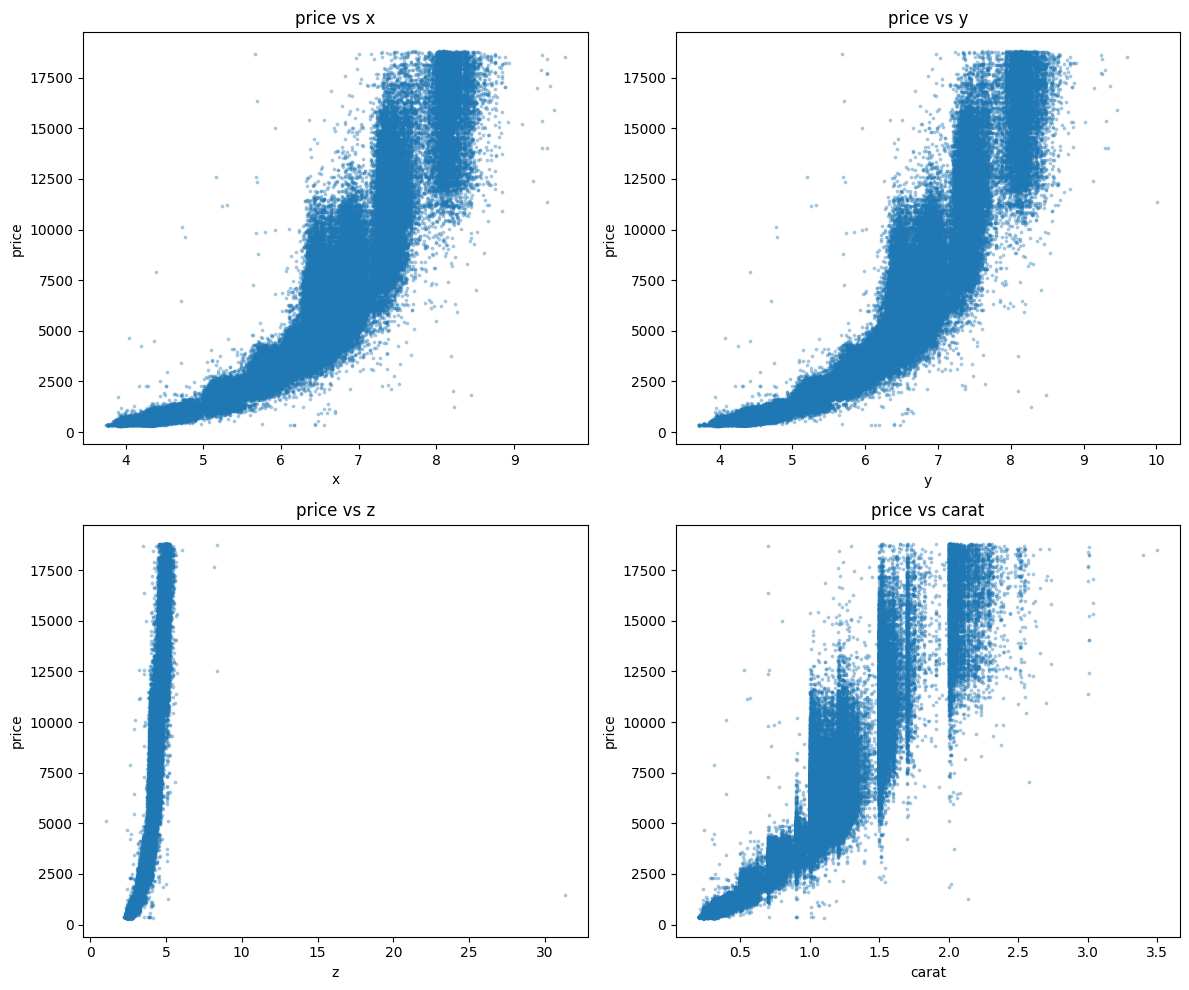

In [591]:
features = ['x', 'y', 'z', 'carat']

fig, axes = plt.subplots(2,2,figsize=(12,10))

for ax, col in zip(axes.flat, features):
    ax.scatter(train[col], train['price'], s=3, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('price')
    ax.set_title(f'price vs {col}')

plt.tight_layout()
plt.show()

there is just few very clear outliar in `z` we will remove it. 

In [592]:
train[train['z']>7]

,carat,cut,color,clarity,depth,table,x,y,z,price
17041,2.01,Premium,I,VS1,59.1,60.0,8.28,8.21,8.18,17640
94237,2.10,Premium,H,I1,61.1,57.0,8.42,8.28,8.35,12512
127668,2.22,Ideal,G,VS2,61.8,57.0,8.36,8.32,8.40,18736
167044,0.51,Premium,G,VS2,61.8,58.0,5.20,5.13,31.30,1447


In [593]:
train = train.drop(train[train['z']>7].index)

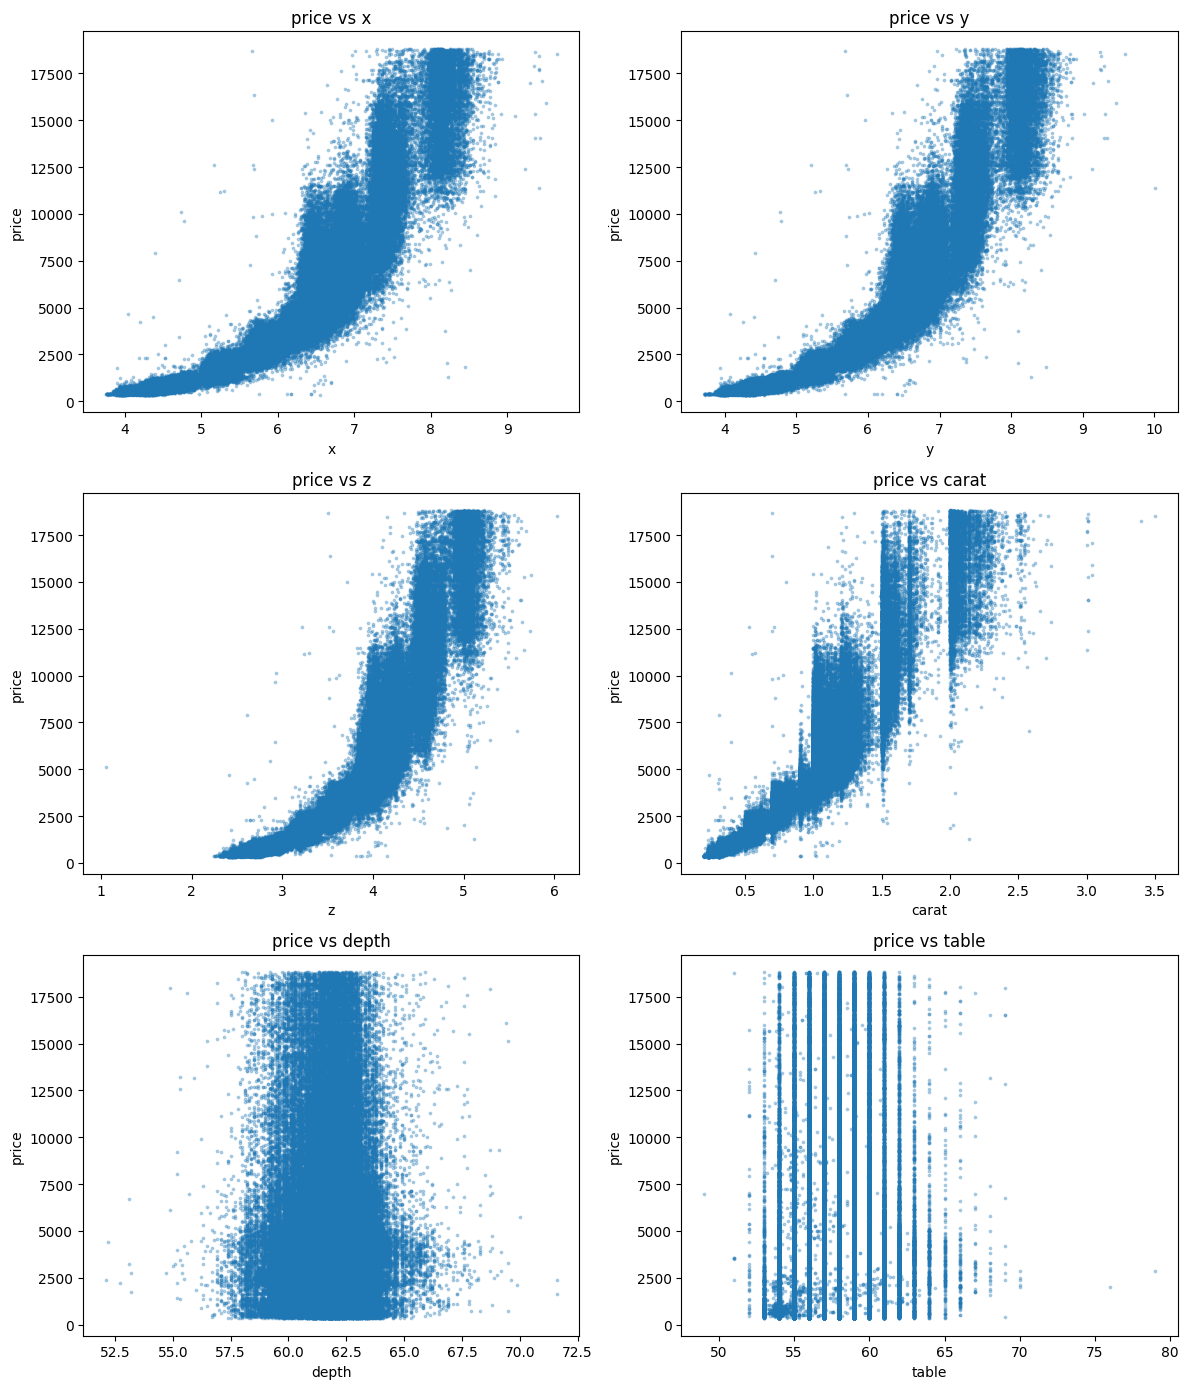

In [594]:
features = ['x', 'y', 'z', 'carat','depth','table']

fig, axes = plt.subplots(3,2,figsize=(12,14))

for ax, col in zip(axes.flat, features):
    ax.scatter(train[col], train['price'], s=3, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('price')
    ax.set_title(f'price vs {col}')

plt.tight_layout()
plt.show()

These plots show the relationship of the features more clearly

In [595]:
corr_matrix = train[['carat','x','y','z']].corr()

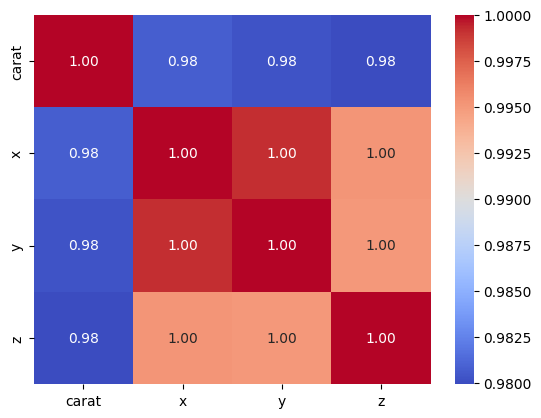

In [596]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

All 4 features are multicollinear to each other.

multicollinearity does not hurt your model's predictions or its score. The model still predicts price perfectly well with all four columns. What it breaks is coefficient interpretation — when x, y, z, carat are 0.98 correlated, the model can't tell which one deserves credit, so it splits the weight between them arbitrarily, and you'll see coefficients that look huge, tiny, or even negative in ways that make no physical sense. 

So if your only goal were leaderboard score, you could technically leave all four in and be fine or deal with this in feature enginerring section. 

 multicollinearity is a coefficient-interpretation problem here, not a prediction problem. 

In [597]:
train.groupby('color', observed=False)['price'].mean().sort_values()

color
D    2976.279308
E    2991.454264
F    3652.098205
G    4113.173827
H    4775.305059
I    5522.166467
J    5756.311183
Name: price, dtype: float64

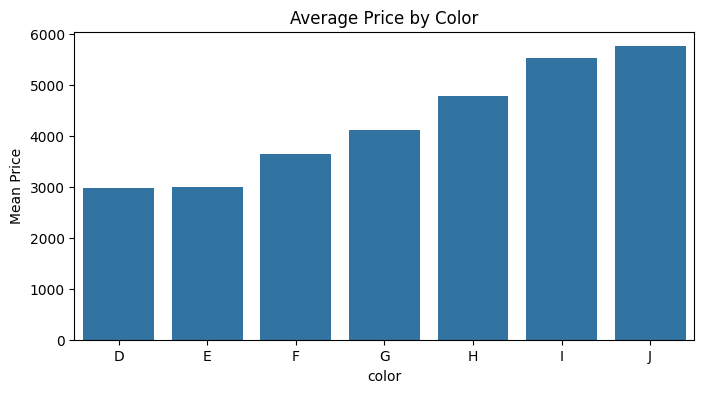

In [598]:
mean_price = train.groupby('color', observed=True)['price'].mean().sort_values()

plt.figure(figsize=(8,4))
sns.barplot(
    x=mean_price.index,
    y=mean_price.values
)
plt.xlabel('color')
plt.ylabel('Mean Price')
plt.title('Average Price by Color')
plt.show()

D → Completely colorless <Br>
E → Nearly colorless<Br>
F → Nearly colorless<Br>
G → Slight trace of color<Br>
H → Slight trace of color<Br>
I → Noticeable warmth<Br>
J → More noticeable yellow/brown tint<Br>

D < E < F < G < H < I < J

The training data follows the order of the colour. 

In [599]:
train.groupby('clarity', observed=False)['price'].mean().sort_values()

clarity
VVS1    2013.440064
IF      2126.509836
VVS2    2966.013069
I1      3522.604697
VS1     3757.947894
VS2     4047.188639
SI1     4140.798427
SI2     5219.068970
Name: price, dtype: float64

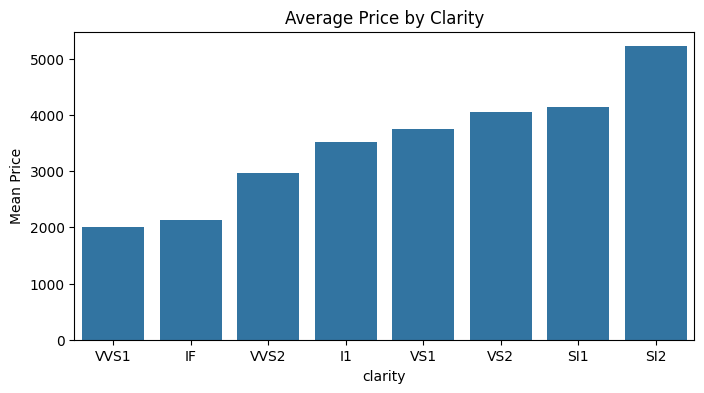

In [600]:
mean_price = train.groupby('clarity', observed=True)['price'].mean().sort_values()

plt.figure(figsize=(8,4))
sns.barplot(
    x=mean_price.index,
    y=mean_price.values,
    order=mean_price.index
)
plt.xlabel('clarity')
plt.ylabel('Mean Price')
plt.title('Average Price by Clarity')
plt.show()

Actual order: IF > VVS1 > VVS2 > VS1 > VS2 > SI1 > SI2 > I1

#### Observation 

The order of the clarity is wrong. The best clarity grades sit at the bottom — VVS1 averages ~$2,013, IF ~$2,127 — while the worst grade SI2 tops the list at ~$5,219. So on average, worse clarity = higher price. Backwards from intuition, exactly the confound.
The mechanism, restated in dollars: SI2 diamonds cost more on average not because flaws are valuable, but because SI2 stones tend to be big. 

So the conclusion holds firmly: clarity looks worthless-or-backwards on its own, but that's only because size is confounding it. In your regression, with carat and clarity both present, the model will recover the true effect among same-size diamonds, better clarity adds value. 

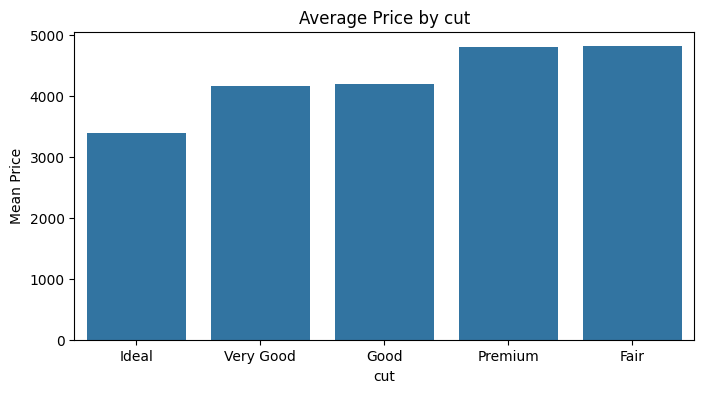

In [601]:
mean_price = train.groupby('cut', observed=True)['price'].mean().sort_values()

plt.figure(figsize=(8,4))
sns.barplot(
    x=mean_price.index,
    y=mean_price.values,
    order=mean_price.index
)
plt.xlabel('cut')
plt.ylabel('Mean Price')
plt.title('Average Price by cut')
plt.show()

Cut is also similar to the clarity. Cut also is not in the order we expected to the price but cut makes more sense when we analyse it with size features.

### Summary of EDA:

- We found multicollinearity in 4 featurres x,y,z and carat.
- We removed some extreme outliars from the z col to make the plot more viz.
- We discovered that colour feature follows the price trends of real world but clarity does not beaucse of size.
- We found that price is right skewed and needs to be normalized.
- The carat and x,y,z size parameters are non linear relationship with the price. So, we will be using the ploynomial regresion.

In [602]:
train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


## Feature Engineering 

In [603]:
train['volume'] = train['x'] * train['y'] * train['z']
test['volume'] = test['x'] * test['y'] * test['z']
train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,volume
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619,242.465405
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387,330.508360
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772,114.112950
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666,52.345818
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453,277.692705


In [604]:
train['density'] = train['carat'] / (train['volume'] + 1e-6)
test['density'] = test['carat'] / (test['volume'] + 1e-6)
train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,volume,density
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619,242.465405,0.006269
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387,330.508360,0.006142
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772,114.112950,0.006134
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666,52.345818,0.006113
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453,277.692705,0.006122


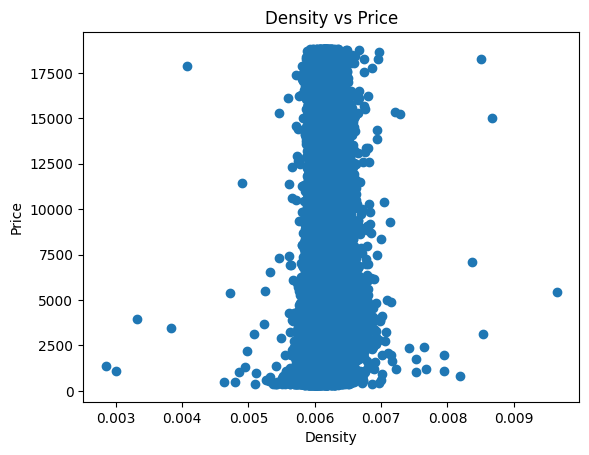

In [605]:
mask = (train['density'] < 0.010)

plt.scatter(train.loc[mask,'density'],train.loc[mask,'price'])
plt.xlabel("Density")
plt.ylabel("Price")
plt.title("Density vs Price")
plt.show()

We have introduced a new features density and volume. Density is almost constant but we experiement with it before removing it since there might be some hidden relationship with other featuers. We can experiment with the model trainig to decide if we want to keep the x,y,z or just volume and similarly for density.

## Data Processing 

#### Encoding 

Since the colour, clarity and cut is ordinal we do Ordinal Encoding to keep the features meaningful. 

In [606]:
num_feats = ["carat",'depth','table','x','y','z','volume'] # default 
cat_feats = ['cut','color','clarity']

In [607]:
X = train[num_feats + cat_feats]
X.describe()

,carat,depth,table,x,y,z,volume
count,193559.000000,193559.000000,193559.000000,193559.000000,193559.000000,193559.000000,193559.000000
mean,0.790626,61.820626,57.227531,5.715273,5.720025,3.534211,128.772482
std,0.462609,1.081650,1.918796,1.109079,1.102069,0.685322,74.782517
min,0.200000,52.100000,49.000000,3.750000,3.710000,1.050000,31.920967
25%,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,64.753136
50%,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,115.215672
75%,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,169.112988
max,3.500000,71.600000,79.000000,9.650000,10.010000,6.030000,558.037305


In [608]:
y = train['price']
y.describe()

count    193559.000000
mean       3968.680656
std        4033.751752
min         326.000000
25%         950.000000
50%        2401.000000
75%        5407.000000
max       18818.000000
Name: price, dtype: float64

<Axes: >

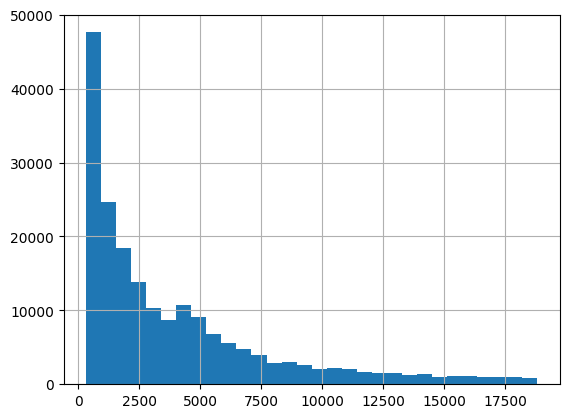

In [609]:
y.hist(bins=30)

<Axes: >

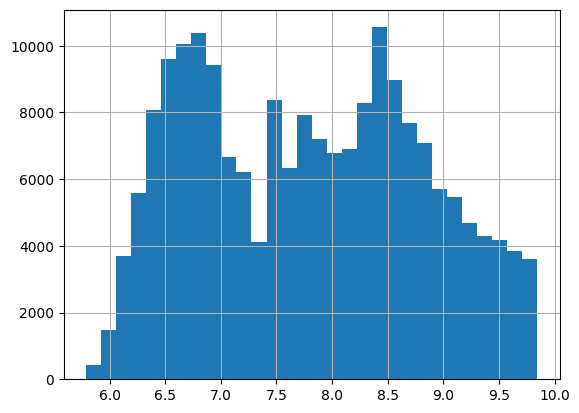

In [610]:
y_log = np.log1p(y)
y_log.hist(bins=30)


#### Why ? 

`log1p` doesn't make the data "relative" — what it changes is **what counts as an equal-sized error.**

On the raw price scale, errors are absolute: being off by 500 is "the same mistake" whether the diamond costs 1,000 or 50,000.

On the log scale, equal distances are equal *ratios*, not equal dollar amounts. log(1000)→log(2000) is the same step as log(20000)→log(40000) — both are "doubling." So a fixed error in log space means a fixed *percentage* error in price.

Why: logs turn multiplication into addition. log(a×k) = log(a) + log(k). So multiplying price by 2 always adds the same constant, no matter the starting price. That's the whole mechanism — ratios become equal steps.

Why it helps here: diamond price spans ~$300 to ~$19,000. Without the log, the model obsesses over the few expensive stones (a 10% error there is huge in dollars) and neglects cheap ones. On the log scale it cares about *percentage* accuracy evenly across the range — which is usually what you actually want, and it tames the skew at the same time.

(The `1p` part = `log(1 + x)`, just so `x=0` doesn't blow up. Undo with `expm1`.)

In [611]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import mean_squared_error

In [612]:
num_pipeline = Pipeline([
    ('poly',PolynomialFeatures(degree=2,include_bias=False)),
    ('scale',StandardScaler())])

pre_process_pipeline = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_feats),
    ('num',num_pipeline,num_feats)])

pipe = Pipeline([('pre',pre_process_pipeline),('model',LinearRegression())])

Note: The whole trick of polynomial regression: you don't make the model nonlinear, you feed it nonlinear features and let it stay linear.

## Model Building 

In [613]:
X[num_feats].replace([np.inf, -np.inf], np.nan).isna().sum()

carat     0
depth     0
table     0
x         0
y         0
z         0
volume    0
dtype: int64

In [614]:
pred_log = cross_val_predict(pipe,X,y_log,cv=5)
pred_price = np.expm1(pred_log)
rmse = np.sqrt(mean_squared_error(train['price'], pred_price))

print(rmse)

890.0352291605354


This is the baseline score we use this to compare new features and improve the model and scores.

Now lets include all the new featues and check the score. 

In [615]:
len(sample) , len(test)

(129050, 129050)

In [616]:
m = pipe.fit(X,y_log)
X_test = test[num_feats+cat_feats]
pred_log = m.predict(X_test)
sample['price'] = np.expm1(pred_log)
sample.to_csv('submission.csv',index=False)

In [617]:
print([f for f in os.listdir() if f.endswith('.csv')])  

['submission.csv']
